# Connect And GetBlockchains

In [2]:
from circular_protocol_api import CircularProtocolAPI,helper

circular = CircularProtocolAPI()
result = circular.getBlockchains()
print(result)

{'Result': 200, 'Response': {'Blockchains': [{'Address': '714d2ac07a826b66ac56752eebd7c77b58d2ee842e523d913fd0ef06e6bdfcae', 'Name': 'Circular Main Public'}, {'Address': 'acb8a9b79f3c663aa01be852cd42725f9e0e497fd849b436df51c5e074ebeb28', 'Name': 'Circular Secondary Public'}, {'Address': 'e087257c48a949710b48bc725b8d90066871fa08f7bbe75d6b140d50119c481f', 'Name': 'Circular Documark Public'}, {'Address': '8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2', 'Name': 'Circular SandBox'}]}, 'Node': 'a15cb668a10ef220f09ae040dce8f180a11efd273a9428f1daeee587ca56343b'}


 # GetWallet


In [3]:
circular.getWallet(blockchain="0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2", 
address="0xa6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5")

{'Result': 200,
 'Response': {'Address': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
  'Assets': [{'Address': '',
    'Amount': '135.000000',
    'Description': 'Circular Coin',
    'EnableSwap': 0,
    'Name': 'CIRX',
    'Price': '1',
    'Royalties': '0',
    'Type': 'C_TYPE_COIN',
    'URL': '',
    'URLType': ''}],
  'ContractData': [],
  'DateCreation': '2025:08:07-09:56:45',
  'LatestTransactions': [{'Amount': 100.0,
    'Asset': 'CIRX',
    'BlockID': 43885,
    'ID': 'cab5e1f9110aa8d15a17d16ccd379a27300c553adcaa5b14f3e03e9837821cc2',
    'Timestamp': '2025:08:11-08:40:50',
    'Type': 'C_TRANSFER',
    'Wallet': '8b1dd25076c04c5139acba458f86c69cd2d322c61d19bc28daa3bbd945083738'},
   {'Amount': -15.5,
    'Asset': 'CIRX',
    'BlockID': 43886,
    'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777',
    'Timestamp': '2025:08:11-08:41:29',
    'Type': 'C_CERTIFICATE',
    'Wallet': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217

# GetAnalytics

In [4]:
circular.getAnalytics(blockchain="0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2")

{'Result': 200,
 'Response': {'Network_ID': 'Testnet',
  'Blockchain': '8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2',
  'Wallets': '245',
  'SmartContracts': '0',
  'SmartContractsTx': '0',
  'Assets': '11',
  'CRC_0123': '11',
  'CRC_0223': '0',
  'CRC_0323': '0',
  'CRC_0XXX': '0',
  'Vouchers': '0',
  'OutVouchers': '0',
  'Transactions': '6032',
  'BroadcastingFees': '2873.000000',
  'TransactionFees': '0.000000',
  'Royalties': '0.000000',
  'CIRXTransfers': '7195386.297918'},
 'Node': 'ab530726847fca7956b6c7ada45f483c6e54e2263ec518c2b3c0490e3b24ba36'}

# Try transactions

In [5]:
from circular_protocol_api import CircularProtocolAPI
from circular_protocol_api import helper
from circular_protocol_api import nag_functions
import json

circular = CircularProtocolAPI()

blockchain = "0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2"
sender ="0xa6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5" 
to = sender # If the particular transaction doesn't necessitate a recipient address, this field can be the same as the sender's address.
privateKey = "0x136ddea8d5b1b5ee3ba3cc013831b71a7dc20ca1b11f3635795f07603ff611a6"

# --- 1. Dati del lotto (JSON) ---
payload = {
    "batch_id": "LOTTO-2025-08-001",
    "type": "raccolta",
    "product": "Latte crudo DOP",
    "quantity": 480,
    "unit": "litri",
    "location": "Parma",
    "timestamp": "2025-08-11T10:05:00Z",
    "parents": ["PARENT-LOTT12", "PARENT-LOTT34"],  # IDs lotti predecessori
    "certification": "DOP",
    "notes": "Raccolta mattutina, temperatura 4°C"
}

timestamp = helper.getFormattedTimestamp()
blockchain = helper.hexFix(blockchain)
print(circular.getWalletNonce(blockchain, sender))
nonce = int(circular.getWalletNonce(blockchain, sender)["Response"]["Nonce"]) + 1
payload = helper.hexFix(json.dumps(payload).encode().hex())
privateKey = helper.hexFix(privateKey)
sender = helper.hexFix(sender)
to = helper.hexFix(to)
ID = str(blockchain + sender + to + payload + str(nonce) + timestamp)

hashID = helper.sha256(ID)
signature = helper.signMessage(hashID, privateKey)
transactionType = "C_TYPE_CERTIFICATE"

'''C_TYPE_CERTIFICATE
Descrizione: Una transazione dove il payload è una stringa generica, tipicamente hashata, e non richiede elaborazione aggiuntiva né è rappresentata da un token.

Uso ideale: Per certificare un evento, uno step o un documento nella filiera senza bisogno di smart contract o asset tokenizzati.

Funziona così: Invii un payload (tipicamente la hash dei dati in JSON, oppure direttamente la stringa, se molto compatta), indicando i riferimenti parent (ID dei lotti precedenti se serve), timestamp, wallet dell’attore.

Vantaggi: È leggera, semplice e pensata proprio per le certificazioni nella supply chain, tracciabilità e attestazioni di processo che non hanno un valore token o asset diretto.'''

data = {
    'ID': hashID,
    'From': sender,
    'To': to,
    'Timestamp': timestamp,
    'Type': transactionType,
    'Payload': payload,
    'Nonce': f"{nonce}",
    'Signature': signature,
    'Blockchain': blockchain,
    'Version': circular.getVersion()
}
print(data)

result = helper.sendRequest(data, nag_functions._SEND_TRANSACTION, circular.getNAGURL())

{'Result': 200, 'Response': {'Nonce': 30}, 'Node': 'fc8fe5ee103dafe353c98ce90a1cb2956fd51a109512e074bd3d26a06d268e81'}
{'ID': '23aab3cfffed9a862a6708a5e5b8695ad25ba365edcc3be298d6d346f541d998', 'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5', 'To': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5', 'Timestamp': '2025:12:07-16:29:53', 'Type': 'C_TYPE_CERTIFICATE', 'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c2022504152454e542d4c4f54543334225d2c202263657274696669636174696f6e223a2022444f50222c20226e6f746573223a2022526163636f6c7461206d6174747574696e612c2074656d706572617475726120

In [6]:
result

{'Result': 200,
 'Response': {'TxID': '23aab3cfffed9a862a6708a5e5b8695ad25ba365edcc3be298d6d346f541d998',
  'Timestamp': '2025:12:07-16:29:53'},
 'Node': 'fc8fe5ee103dafe353c98ce90a1cb2956fd51a109512e074bd3d26a06d268e81'}

In [7]:
tx_id=result["Response"]["TxID"]
tx_id

'23aab3cfffed9a862a6708a5e5b8695ad25ba365edcc3be298d6d346f541d998'

# Get transactions

## by ID

In [8]:
txid="23aab3cfffed9a862a6708a5e5b8695ad25ba365edcc3be298d6d346f541d998"

blockchain="0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2"

res= circular.getTransactionByID(blockchain,txid,"0","67") #start ed end?
res

{'Result': 200,
 'Response': {'BlockID': '70391',
  'BroadcastFee': 1.0,
  'Check': 'ced792b6b051f6d16adaa1dcd3cbed91e9eaae785324172eda0333ac0b7e61db',
  'DeveloperFee': 0.0,
  'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
  'GasLimit': 0.0,
  'ID': '23aab3cfffed9a862a6708a5e5b8695ad25ba365edcc3be298d6d346f541d998',
  'Instructions': 0,
  'NagFee': 0.5,
  'NodeID': 'fc8fe5ee103dafe353c98ce90a1cb2956fd51a109512e074bd3d26a06d268e81',
  'Nonce': '31',
  'OSignature': '3045022100addae40bbe484ac9f656874998a233cc3efca72d442e2ba1263e8ff60cacc7e90220627dd475cd2177b4bea6f0a5853401291468d6c1c621affbf7faf979b5a1bb11',
  'Outcome': 'Stored',
  'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30

### Torno da HEX a STR

In [9]:
# Questo è il payload esadecimale ottenuto da getTransactionByID
payload_hex = res["Response"]["Payload"]

# 1. Converto da hex a bytes
payload_bytes = bytes.fromhex(payload_hex)

# 2. Converto i bytes in stringa UTF-8
payload_str = payload_bytes.decode("utf-8")

# 3. Converto la stringa in oggetto Python (dizionario) se è JSON
payload_json = json.loads(payload_str)

print("JSON originale della transazione:")
print(json.dumps(payload_json, indent=2, ensure_ascii=False))

JSON originale della transazione:
{
  "batch_id": "LOTTO-2025-08-001",
  "type": "raccolta",
  "product": "Latte crudo DOP",
  "quantity": 480,
  "unit": "litri",
  "location": "Parma",
  "timestamp": "2025-08-11T10:05:00Z",
  "parents": [
    "PARENT-LOTT12",
    "PARENT-LOTT34"
  ],
  "certification": "DOP",
  "notes": "Raccolta mattutina, temperatura 4°C"
}


## By address of sender

In [26]:
res=circular.getTransactionsByAddress(blockchain, sender, "0", "10")
res

{'Result': 200,
 'Response': [{'BlockID': '43886',
   'BroadcastFee': 1.0,
   'DeveloperFee': 0.0,
   'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
   'GasLimit': 0.0,
   'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777',
   'Instructions': 0,
   'NagFee': 0.5,
   'NodeID': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4',
   'Nonce': '1',
   'OSignature': '30440220030b8cb90a0efb3c2ae7f7327634dd544d005896fa30070b01ce8ba09041f2b40220722f51380c2453e753c7674ce4928fdd067f79928e5b00333d75a55a0ab01d66',
   'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c202

In [32]:
type(res)
res.keys()
res["Response"][0]

{'BlockID': '43886',
 'BroadcastFee': 1.0,
 'DeveloperFee': 0.0,
 'From': 'a6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5',
 'GasLimit': 0.0,
 'ID': '6638b10baab16c8b674983a723a8e81ec106e7804b097044ebb9cc92fba81777',
 'Instructions': 0,
 'NagFee': 0.5,
 'NodeID': '7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4',
 'Nonce': '1',
 'OSignature': '30440220030b8cb90a0efb3c2ae7f7327634dd544d005896fa30070b01ce8ba09041f2b40220722f51380c2453e753c7674ce4928fdd067f79928e5b00333d75a55a0ab01d66',
 'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c2022504152454e542d4c4f54543334225d2c2022636572746966696

## by Date and address 

In [11]:
blockchain = "0x8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2"
wallet_address = "0xa6c39da22421e9a08f08f8030dc6c40221df0cf815cd844ec217f56980a532f5"
start_date = "2025:07:12-11:59:11"
end_date = "2026:10:11-15:23:23"

result = circular.getTransactionByDate(blockchain, wallet_address, start_date, end_date)

print(result)


{'Result': 131, 'Response': 'Blockchain File Corrupted', 'Node': 'ca7ff7cc5d30979d2238f0032fe1f1a79ab95b99cbb276c0cf72c66b0870d08c'}


# RETRIEVE ENV VARS

In [12]:
from dotenv import load_dotenv #pip install python-dotenv
import os

# Carica il file .env
load_dotenv()

blockchain=os.getenv("Blockchain")


## DB

In [5]:
import os
from dotenv import load_dotenv
import mysql.connector
from mysql.connector import Error

def connect_to_db():
    # Carica variabili dal file .env
    load_dotenv()

    # Recupera variabili ambiente
    host = os.getenv("MYSQL_HOST")
    port = int(os.getenv("MYSQL_PORT", 3306))
    user = os.getenv("MYSQL_USER")
    password = os.getenv("MYSQL_PASSWORD")
    database = os.getenv("MYSQL_DATABASE")
    try:
        # Connessione al database
        connection = mysql.connector.connect(
            host=host,
            port=port,
            user=user,
            password=password,
            database=database
        )

        if connection.is_connected():
            print("✅ Connessione al database avvenuta con successo!")
            cursor = connection.cursor()
            cursor.execute("SELECT DATABASE();")
            record = cursor.fetchone()
            print(f"📂 Database attuale: {record[0]}")
            cursor.execute("SELECT * FROM user;")
            rows = cursor.fetchall()
            print("👥 Utenti nel database:"f"\n{rows}")


    except Error as e:
        print(f"❌ Errore durante la connessione a MySQL: {e}")

    finally:
        if 'connection' in locals() and connection.is_connected():
            cursor.close()
            connection.close()
            print("🔌 Connessione chiusa.")

connect_to_db()


✅ Connessione al database avvenuta con successo!
📂 Database attuale: smartfood
👥 Utenti nel database:
[(1, 'Dom', 'Produttore', 'mimmo@gmail.com', '0x123', datetime.datetime(2025, 8, 12, 11, 15, 57), 1, 'ciao')]
🔌 Connessione chiusa.


In [ ]:
from utils import get_db_connection
conn = get_db_connection()
cursor = conn.cursor(dictionary=True)
tx_id="0xfa6522f0f4a1808f21645f44c5d4abf58feb38d1c0068dec1745206c3f448ce3"
cursor.execute("SELECT * FROM transaction_qrcode WHERE tx_id=%s", (tx_id,))
result = cursor.fetchone()
print(result)

{'tx_id': '0xfa6522f0f4a1808f21645f44c5d4abf58feb38d1c0068dec1745206c3f448ce3', 'qrcode_img': 'iVBORw0KGgoAAAANSUhEUgAAAeoAAAHqAQAAAADjFjCXAAAEK0lEQVR4nO2dW4rjSBBFT4wE/pSgFlBLSe1gllRr6h1IS/ECGqTPgjQxH/lQuj0zMJaG6sI3PowfdUgESTxuRGaZc8CWP47QIFy4cOHChQsXLvxc3LL1sFiP2QjAzcoL2LSZpRczM5vOW134i+LB3d1XIKwA3Mym7eIsY+dm481gcPeZzt3d/R4/uLrwF8NJeyisQFi7tJvazTVE3FdwXzsvf9J52qfzt3524b8NHjxiU/J1PYTrxVneY4q6Pv/Pqwt/Cbx/+GZ7c9hGHD7N4dOAi7P8+dMexL1v/ezCvwovETbldV0KqYQVfB7cYXAneEypH2EtoVcRVvhRfDGzVLmG6yVlbvZx7SFce2C7OGw9wC2VsKeuLvzF8BRhm8i5vEdKXAVf3nOYdbZUyJ65uvDXxNsallS5xlLNDp5tJgfcJK5QKlxFWOHH8M59HiJmdinurCrCH+6eVWK6tEVtOnV14S+Fk53WEBu9LpcPxeGlv5uHXEMQPCJfJ/yAlYo01hjalX21Qi5p/e4lKcfadcKftaLXbSOw9REoxcUygbP1+DKuzlLqVl+mqvJ962cX/lU4Xq3EVdgLiSLfFf83k3+VXif8gO2aL9DdycJr7simkNq8U4QVfshqhH2LpXS99Szj6sYQe4MUcN2C34zwIwMW5hNWF/6aeHFa6UPpiNV3uUvGg9eTrxN+wJoIm1I1yixTshJNm7q2tmW164Q/Z7/4ur1VkYUUr0N2e9WxytcJP47bBBD809Lc8DJ2ud2/WB4BsAlIQ+45CJ+2uvBXw9veBNCoJK2QQsnrQnWMirDCn7d9191F06zNpR/ypF31cIPyOuGHLGdotQWbkruVf+vDK

In [19]:
result.get("qr_url")


'https://localhost:8000/filiera/view/0xfa6522f0f4a1808f21645f44c5d4abf58feb38d1c0068dec1745206c3f448ce3'

# SERVER

# Decodifica da base4


In [19]:
import base64
from PIL import Image
from io import BytesIO
import os
import matplotlib.pyplot as plt
def show_qr_from_base64(img_base64: str):
    # Decodifica da base64 a bytes
    img_bytes = base64.b64decode(img_base64)

    # Carica l'immagine da buffer
    img = Image.open(BytesIO(img_bytes))


    # Mostra direttamente in una finestra matplotlib
    plt.imshow(img)
    plt.axis("off")
    plt.show()


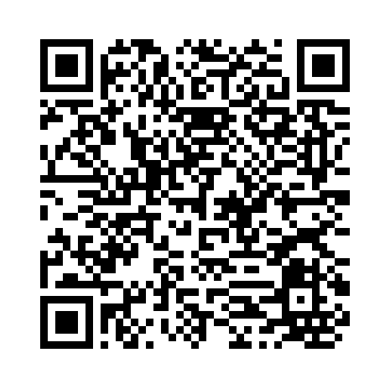

In [21]:
show_qr_from_base64("iVBORw0KGgoAAAANSUhEUgAAAeoAAAHqAQAAAADjFjCXAAAD+UlEQVR4nO2dTYqkShSFz30KNQyhFlBL0R30kopeUu8gXUotoCAcJkRy3iB+zez3Bipk23nuQNT0QwIu999II3bI/M8eGhAuXLhw4cKFCxd+LG5JegBLj3SGm2EebhYfmXAzYMmPTse9Xfir4SBJYiRJ+o68AIgH+o4AOvLiAgCXH6nE5dRrF/5sfEnmyz5JAo60yQXwgpvZ59cbyS9LVi9ZwgPfLvy18P7hzvIebPS3Pp0RwDzAOP/4TZHl1GsX/iz8Qeuihg3fANzViGUA4DwMMDzo3anXLvzZuGMM6QDHqFv8OXQ0+yAx+puRJG0CQDIc/Hbhr4WnbCJJR4z+/w/5UWUTwjdL9LCt53QBnIcuXc0fAYC7GoCbAW7tZE+9duHPwnPlxAMoVZK2VELmakqsnOTnKFsnfLMk9XGpBIeiUnfeNJ0VNysPK3y75Liua01aNHhIVeLodS+O8SyVlKV1wjdL22mIKhWyNy2p6shQDivVk9YJ3yTFbjV2LateiFWSZOYAJKunuE74Psk6V31o1r8x9mERo7mkhB6Ij8jWCd8uNXMgfQnzXEC8V8O8OAzgqhGU1gnfKKUj1gWDC/WSBhd6A/pgowdt/AUQy7qFduq1C38W3lROYtI61gId0KQPuYanuE74oVrHnEOkUl3UsDxpV5ywcljhh3hYA+LsHGz8eqMBAOcfHW307wHAzTh/EIAjLOa6R7xd+GviTeXkriMRHWnypiW5KE5YHlb4dslJa4nmSr461oCvtCpK1CcPK3yHJKvls0mL93zOJuACUMvHKPekdcK3S/KrJNvc1CVNrEOe6cxVFZXWCd8qWetKp9W3P9SUtmpn7JdJ64RvlzaV8O1HiW0LArVLsbaJp1678Gfh67iOpfvaNUpYp+pUrxN+ID4PN8NsPfjz42qkB2xydRggDq/TbEAeBjjw7cJfDH+cOYkFkmLNcr2uGTdpRttPvXbhz8Kx8qtt9/W+QNf4VcV1wvdJ1Lp2O5M0y3lfEU5h3toSnnrtwp+F3++uk91naUb4rhlZj8ioep3wfXJXr6tllHaCuNyrH+9I64Rvl6xh9U61cCVpKD8AgL5MFH74zMl6yK5qWIn1FNcJ34mX+ToAQBcYL11HA7oALF3AbADnCQCW94B58JqvE75HHrIJoOSwD8ZNfVjhR+BtXFfy1eRt6w6xANrpk1rIO/Xahf8x+Pj1RpuWHja5q/HirmafJNMOsfG7nav9F77z7cJfAn/cITZ+IxEALO80uI6Yh++e89QFzFMPA94U1wnfI3dx3Wp4vex4UiZSSpdWcZ3wHZK1CUDT+L/b4B9otj2B9q8Tvg83/XudcOHChQsXLlz4X4H/C8TttTEFFiW/AAAAAElFTkSuQmCC")

# PDF


In [ ]:
from utils import generate_pdf_bytes,define_qr_code
qr_code_img = define_qr_code(url="",base_url="cisfa.net",tx_id=2)

data={'ID': 'f3cb7a83b57e6b9aeb2103e61673406dbf098984bc579dc4914b72c047082eac', 'From': '95ac5cd4da43eae81b3e361193774f1206df5ef6acd1e165bacbe099884c43ad', 'To': '95ac5cd4da43eae81b3e361193774f1206df5ef6acd1e165bacbe099884c43ad', 'Timestamp': '2025:08:21-10:17:11', 'Type': 'C_TYPE_CERTIFICATE', 'Payload': '7b2262617463685f6964223a20224c4f54544f2d323032352d30382d303031222c202274797065223a2022726163636f6c7461222c202270726f64756374223a20224c6174746520637275646f20444f50222c20227175616e74697479223a203438302c2022756e6974223a20226c69747269222c20226c6f636174696f6e223a20225061726d61222c202274696d657374616d70223a2022323032352d30382d31315431303a30353a30305a222c2022706172656e7473223a205b22504152454e542d4c4f54543132222c2022504152454e542d4c4f54543334225d2c202263657274696669636174696f6e223a2022444f50222c20226e6f746573223a2022526163636f6c7461206d6174747574696e612c2074656d706572617475726120345c753030623043227d', 'Nonce': '1', 'Signature': '304402201cdb3b864637d790d2247bc8ae2a8e51d7e6cab64ab5dd4b32a66916166a8622022069fe6a9c319a62b0ca8c6af9ded1a93b146e30d660ddf62a23e961fa41a3716f', 'Blockchain': '8a20baa40c45dc5055aeb26197c203e576ef389d9acb171bd62da11dc5ad72b2', 'Version': '1.0.8'}
pdf_file = generate_pdf_bytes(data,qr=qr_code_img, filename=f"certificate_{2}.pdf")

Errore durante l'inserimento del QR code: 1364 (HY000): Field 'block_id' doesn't have a default value


TypeError: expected str, bytes or os.PathLike object, not BytesIO

In [18]:
import re

def extract_fields_from_pdf_text(text):
    """
    Estrae tutti i campi dal testo del PDF certificato
    """
    import re

def extract_specific_fields(text):
    """
    Usa regex specifici per ogni campo
    """
    fields = {}
    
    # Pattern per ogni campo
    patterns = {
        'ID': r'ID:\s*([a-f0-9\s]+?)(?=\s*BlockID:|$)',
        'BlockID': r'BlockID:\s*(\d+)',
        'From': r'From:\s*([a-f0-9\s]+?)(?=\s*To:|$)',
        'To': r'To:\s*([a-f0-9\s]+?)(?=\s*NodeID:|$)',
        'NodeID': r'NodeID:\s*([a-f0-9\s]+?)(?=\s*Timestamp:|$)',
        'Timestamp': r'Timestamp:\s*([\d:\-]+)',
        'Type': r'Type:\s*([A-Z_]+)',
        'Status': r'Status:\s*(\w+)',
        'Payload': r'Payload:\s*([a-f0-9\s]+?)(?=\s*OSignature:|$)',
        'OSignature': r'OSignature:\s*([a-f0-9\s]+?)(?=\s*Page|$)'
    }
    
    # Rimuovi \n per semplificare il matching
    clean_text = text.replace('\n', ' ')
    
    for field, pattern in patterns.items():
        match = re.search(pattern, clean_text, re.IGNORECASE)
        if match:
            # Rimuovi spazi extra
            value = re.sub(r'\s+', '', match.group(1)) if field != 'Timestamp' else match.group(1)
            fields[field] = value
    
    return fields







In [20]:
# importing required classes
from pypdf import PdfReader

# creating a pdf reader object
reader = PdfReader('certificate_0xd8a6db18215dd763c539fcfb30ec6fb3442c91a19150a3143395cbdcbfc83ab1.pdf')

# printing number of pages in pdf file
print(len(reader.pages))

# creating a page object
page = reader.pages[0]

# extracting text from page
#print(page.extract_text())
# Uso
text = page.extract_text()
# Uso
fields = extract_specific_fields(text)
for field, value in fields.items():
    print(f"{field}: {value}")


1
ID: d8a6db18215dd763c539fcfb30ec6fb3442c91a19150a3143395cbdcbfc83ab1
BlockID: 44110
From: 95ac5cd4da43eae81b3e361193774f1206df5ef6acd1e165bacbe099884c43ad
To: 95ac5cd4da43eae81b3e361193774f1206df5ef6acd1e165bacbe099884c43ad
NodeID: 7bb5bd50729d6857942701d5673ea70ca1625f883230d8543970a452d1abe1c4
Timestamp: 2025:08:23-13:06:12
Type: C_TYPE_CERTIFICATE
Status: Executed
Payload: 7b2262617463685f6964223a202241313233343536222c202274797065223a2022526163636f6c7461222c202270726f64756374223a20224f6c697665222c20227175616e74697479223a203231332c2022756e6974223a2022707a222c20226c6f636174696f6e223a202256696120436f6d756e616c652053616e746f2c2053616e746f2c2049494920436972636f736372697a696f6e652c2053616e2046696c6970706f20496e666572696f72652c204d657373696e612c20536963696c69612c2039383132372c204974616c6961222c202274696d657374616d70223a2022323032352d30382d32335431333a30363a30305a222c2022706172656e7473223a205b5d2c202263657274696669636174696f6e223a2022222c20226e6f746573223a2022227d
OSignature: 3045022044da